# AdaBoost Demo – Step‑by‑Step Walkthrough

This notebook demonstrates how the AdaBoost algorithm builds an ensemble of weak learners by iteratively reweighting training samples and combining multiple decision trees (stumps). [file:1]

---

## 1. Imports and Setup

We begin by importing the required libraries and setting up an empty DataFrame. [file:1]

```python
import pandas as pd
import numpy as np
from mlxtend.plotting import plot_decision_regions

df = pd.DataFrame()
```

---

## 2. Create a Toy Dataset

We manually construct a small 2‑dimensional dataset with a binary label to make the AdaBoost process easy to follow. [file:1]

```python
df['X1'] =[1]
df['X2'] =[1]
df['label'] =[1]
df
```

Each row is one sample, with features \((X1, X2)\) and target `label` in \(\{0,1\}\). [file:1]

---

## 3. Initialize Sample Weights

AdaBoost starts with equal weights for all training samples. For 10 points, each weight is \(1/10 = 0.1\). [file:1]

```python
n_samples = len(df)
df['weights'] = np.full(n_samples, 1.0 / n_samples)
df
```

Now every row has a `weights` column set to 0.1. These weights will be updated after each weak learner is trained. [file:1]

---

## 4. Train the First Weak Learner

We now train the first base classifier (typically a decision stump) using the current weights. Conceptually, the steps are: [file:1]

1. Fit a weak learner \(h_1(x)\) to the data using `weights` so misclassified points matter more in the loss. [file:1]  
2. Predict labels for all samples and store them as `y_pred`. [file:1]

Illustrative code (your notebook may use a specific API or custom logic here):

```python
from sklearn.tree import DecisionTreeClassifier

X = df[['X1', 'X2']].values
y = df['label'].values
w = df['weights'].values

clf_1 = DecisionTreeClassifier(max_depth=1)
clf_1.fit(X, y, sample_weight=w)

df['y_pred'] = clf_1.predict(X)
df
```

At this stage you see which points are correctly vs incorrectly classified by the first stump in the `y_pred` column. [file:1]

---

## 5. Compute Weighted Error and Alpha (Learner Weight)

AdaBoost measures how well the weak learner performs under the current distribution of weights. [file:1]

1. Compute the **weighted error**  
   \[
   \epsilon_1 = \sum_{i: y_i \neq h_1(x_i)} w_i
   \]
   where the sum is only over misclassified samples. [file:1]

2. Compute the **learner weight** (alpha)  
   \[
   \alpha_1 = \frac{1}{2} \ln\left(\frac{1 - \epsilon_1}{\epsilon_1}\right)
   \]
   A smaller error gives a larger \(\alpha\). [file:1]

Example code:

```python
incorrect = (df['label'] != df['y_pred']).astype(int)
epsilon_1 = np.sum(df['weights'] * incorrect)

alpha_1 = 0.5 * np.log((1 - epsilon_1) / epsilon_1)
epsilon_1, alpha_1
```

---

## 6. Update Sample Weights

After computing \(\alpha_1\), we increase the weights of misclassified samples and decrease the weights of correctly classified ones. [file:1]

The update rule for each sample \(i\) is:

\[
w_i^{(new)} = w_i^{(old)} \cdot \exp\left(\alpha_1 \cdot I[y_i \neq h_1(x_i)]\right)
\]

where \(I[\cdot]\) is 1 if the condition is true and 0 otherwise. [file:1]

Illustrative code:

```python
df['updated_weights'] = df['weights'] * np.exp(
    alpha_1 * incorrect  # 1 for misclassified, 0 for correct
)
df
```

You will see higher `updated_weights` for the misclassified points. [file:1]

---

## 7. Normalize Weights

AdaBoost normalizes the weights so that they sum to 1 again. This defines a new distribution over the training data for the next weak learner. [file:1]

```python
Z_1 = df['updated_weights'].sum()        # Normalization factor
df['normalized_weights'] = df['updated_weights'] / Z_1
df
```

Now `normalized_weights` represents the probability distribution \(D_2\) that the second weak learner will use. [file:1]

---

## 8. Build the Cumulative Distribution (Sampling Intervals)

To intuitively show how AdaBoost focuses more on hard points, the notebook constructs cumulative sums over these normalized weights. [file:1]

```python
df = df.sort_index()  # or specific ordering you used

df['cumsum_lower'] = df['normalized_weights'].shift(fill_value=0).cumsum()
df['cumsum_upper'] = df['normalized_weights'].cumsum()
df
```

Each interval \([cumsum\_lower, cumsum\_upper)\) corresponds to one sample; larger intervals mean higher probability of being sampled for the next learner. [file:1]

This is a visualization of how the reweighting changes the effective sampling distribution. [file:1]

---

## 9. (Optional) Resample According to New Weights

To further illustrate the effect of the new distribution, the notebook may resample training points with replacement using the normalized weights. Points with high weights appear more often in the resampled dataset. [file:1]

Example:

```python
resampled_indices = np.random.choice(
    np.arange(n_samples),
    size=n_samples,
    replace=True,
    p=df['normalized_weights'].values
)

df_resampled = df.iloc[resampled_indices][['X1', 'X2', 'label', 'weights']]
df_resampled
```

You see some rows repeated many times and some rarely or not at all, showing which samples the next weak learner will focus on. [file:1]

---

## 10. Train the Second Weak Learner

We now train a second weak learner \(h_2(x)\) on the resampled (or reweighted) data. This learner is forced to pay more attention to samples that were misclassified by \(h_1\). [file:1]

```python
X2 = df_resampled[['X1', 'X2']].values
y2 = df_resampled['label'].values

clf_2 = DecisionTreeClassifier(max_depth=1)
clf_2.fit(X2, y2)

df_resampled['y_pred'] = clf_2.predict(X2)
df_resampled
```

We then repeat the same steps: compute \(\epsilon_2\), \(\alpha_2\), update weights, normalize, and optionally build new cumulative sums. [file:1]

---

## 11. Repeat for Additional Rounds

The notebook continues this process for a third (and possibly more) weak learner: [file:1]

1. Train stump \(h_t(x)\) using current weights.  
2. Compute weighted error \(\epsilon_t\) and learner weight \(\alpha_t\).  
3. Update and normalize sample weights.  
4. (Optionally) visualize weights, cumulative sums, and resampled datasets. [file:1]

This iterative reweighting is the core of AdaBoost’s learning procedure. [file:1]

---

## 12. Final Strong Classifier

After \(T\) rounds, AdaBoost combines all the weak learners into a final strong classifier:

\[
H(x) = \text{sign}\left( \sum_{t=1}^{T} \alpha_t \cdot h_t(x) \right)
\]

Conceptually, each stump votes with strength \(\alpha_t\), and the final prediction is the sign of the weighted sum of these votes. [file:1]

You can implement this as:

```python
def adaboost_predict(clfs, alphas, X):
    # clfs: list of fitted weak learners [clf_1, clf_2, ...]
    # alphas: corresponding list of alpha values [alpha_1, alpha_2, ...]
    final_score = np.zeros(X.shape)
    for alpha, clf in zip(alphas, clfs):
        preds = clf.predict(X)
        # map {0,1} to {-1,+1}
        preds_mapped = np.where(preds == 1, 1, -1)
        final_score += alpha * preds_mapped
    return (final_score > 0).astype(int)
```

---

## 13. Visualizing Decision Regions (Optional)

To better understand how AdaBoost changes the decision boundary, we can use `plot_decision_regions` from `mlxtend`. [file:1]

```python
X = df[['X1', 'X2']].values
y = df['label'].values

# Suppose you have the final AdaBoost classifier 'ada_clf'
plot_decision_regions(X=X, y=y, clf=ada_clf, legend=2)
```

This plot shows how the ensemble of stumps creates a more complex decision boundary than any single stump alone. [file:1]

---

## 14. Key Intuitions from the Demo

- AdaBoost starts with uniform sample weights and gradually shifts attention toward hard‑to‑classify points. [file:1]  
- Each weak learner focuses more on mistakes made by previous learners. [file:1]  
- The final model is a weighted vote of many simple models (stumps), often leading to strong performance even though individual learners are weak. [file:1]

This notebook, using a tiny dataset, makes each weight update and sampling step explicit so you can follow the algorithm numerically rather than treating it as a black box. [file:1]

In [2]:
import pandas as pd
import numpy as np
from mlxtend.plotting import plot_decision_regions

In [7]:
df=pd.DataFrame()

In [8]:
df['X1']=[1,2,3,4,5,6,6,7,9,9]
df['X2']=[5,3,6,8,1,9,5,8,9,2]
df['label']=[1,1,0,1,0,1,0,1,0,0]

In [9]:
df

,X1,X2,label
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0
5,6,9,1
6,6,5,0
7,7,8,1
8,9,9,0
9,9,2,0


In [10]:
import seaborn as sns

<Axes: xlabel='X1', ylabel='X2'>

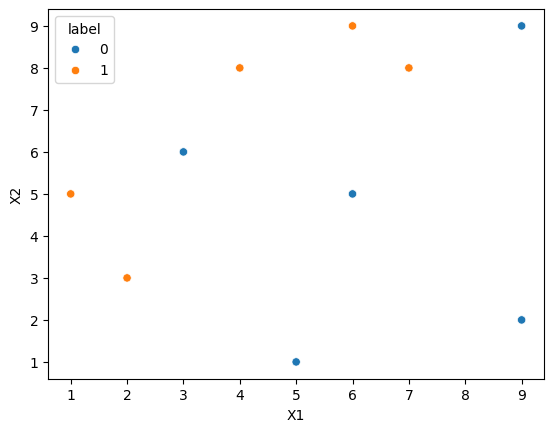

In [12]:
sns.scatterplot(x=df['X1'],y=df['X2'],hue=df['label'])

In [13]:
#assigning weight
df['weights']=1/df.shape[0]

In [14]:
df

,X1,X2,label,weights
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1
5,6,9,1,0.1
6,6,5,0,0.1
7,7,8,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1


In [16]:
from sklearn.tree import DecisionTreeClassifier

In [17]:
dt1=DecisionTreeClassifier(max_depth=1) #decision stumps as depth should be 1

In [18]:
X=df.iloc[:,0:2].values
Y=df.iloc[:,2].values

In [19]:
dt1.fit(X,Y)

,criterion,'gini'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


[Text(0.5, 0.75, 'x[1] <= 2.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.469\nsamples = 8\nvalue = [3, 5]'),
 Text(0.625, 0.5, '  False')]

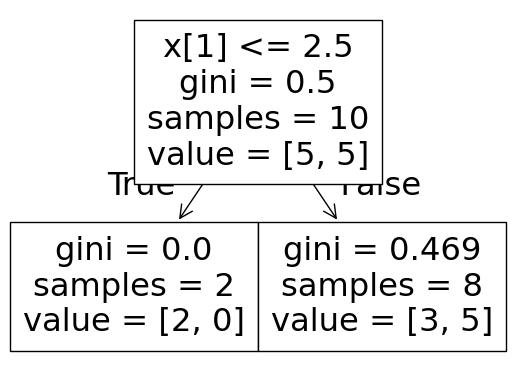

In [21]:
from sklearn.tree import plot_tree
plot_tree(dt1)

<Axes: >

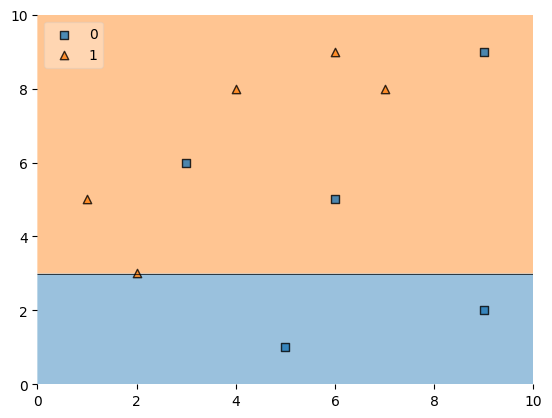

In [22]:
plot_decision_regions(X,Y,clf=dt1,legend=2)

In [23]:
df['y_pred']=dt1.predict(X)

In [24]:
df # row number 2 ,6,8 it had made mistake

,X1,X2,label,weights,y_pred
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,1
3,4,8,1,0.1,1
4,5,1,0,0.1,0
5,6,9,1,0.1,1
6,6,5,0,0.1,1
7,7,8,1,0.1,1
8,9,9,0,0.1,1
9,9,2,0,0.1,0


In [25]:
#total error .1 +.1 +.1 = 0.3 because it had made three mistake


In [61]:
def calculate_model_weight(error):
    return 0.5*np.log((1-error)/(error+0.0000001))

In [28]:
#STep3 calculate model weight
alpha1=calculate_model_weight(0.3)
alpha1

np.float64(0.42364893019360184)

In [33]:
# step4 - update weights
def update_row_weights(row,alpha=.423):
    if row['label'] == row['y_pred']:
        return row['weights']*np.exp(-alpha)
    else:
        return row['weights']*np.exp(alpha)

In [ ]:
#why multiply with e to power alpha
# alpha is high when model is good
#when it does veey less mistake

In [34]:
df['updated_weights']=df.apply(update_row_weights,axis=1)

In [35]:
df

,X1,X2,label,weights,y_pred,updated_weights
0,1,5,1,0.1,1,0.065508
1,2,3,1,0.1,1,0.065508
2,3,6,0,0.1,1,0.152653
3,4,8,1,0.1,1,0.065508
4,5,1,0,0.1,0,0.065508
5,6,9,1,0.1,1,0.065508
6,6,5,0,0.1,1,0.152653
7,7,8,1,0.1,1,0.065508
8,9,9,0,0.1,1,0.152653
9,9,2,0,0.1,0,0.065508


In [36]:
df['updated_weights'].sum()

np.float64(0.9165153319682015)

In [37]:
#since sum is .916 we need to normlize

In [38]:
df['normalized_weights']=df['updated_weights']/df['updated_weights'].sum()

In [39]:
df

,X1,X2,label,weights,y_pred,updated_weights,normalized_weights
0,1,5,1,0.1,1,0.065508,0.071475
1,2,3,1,0.1,1,0.065508,0.071475
2,3,6,0,0.1,1,0.152653,0.166559
3,4,8,1,0.1,1,0.065508,0.071475
4,5,1,0,0.1,0,0.065508,0.071475
5,6,9,1,0.1,1,0.065508,0.071475
6,6,5,0,0.1,1,0.152653,0.166559
7,7,8,1,0.1,1,0.065508,0.071475
8,9,9,0,0.1,1,0.152653,0.166559
9,9,2,0,0.1,0,0.065508,0.071475


In [40]:
df['normalized_weights'].sum()

np.float64(1.0)

In [41]:
#now normalized wegiths sum is equal to 1

In [43]:
df['cumsum_upper']=np.cumsum(df['normalized_weights'])

In [44]:
#now we will create range
df['cumsum_lower']=df['cumsum_upper'] - df['normalized_weights']

In [45]:
df

,X1,X2,label,weights,y_pred,updated_weights,normalized_weights,cumsum_upper,cumsum_lower
0,1,5,1,0.1,1,0.065508,0.071475,0.071475,0.000000
1,2,3,1,0.1,1,0.065508,0.071475,0.142950,0.071475
2,3,6,0,0.1,1,0.152653,0.166559,0.309508,0.142950
3,4,8,1,0.1,1,0.065508,0.071475,0.380983,0.309508
4,5,1,0,0.1,0,0.065508,0.071475,0.452458,0.380983
5,6,9,1,0.1,1,0.065508,0.071475,0.523933,0.452458
6,6,5,0,0.1,1,0.152653,0.166559,0.690492,0.523933
7,7,8,1,0.1,1,0.065508,0.071475,0.761967,0.690492
8,9,9,0,0.1,1,0.152653,0.166559,0.928525,0.761967
9,9,2,0,0.1,0,0.065508,0.071475,1.000000,0.928525


In [46]:
def create_new_dataset(df):
    indices=[]

    for i in range(df.shape[0]):
        a=np.random.random()
        for index,row in df.iterrows():
            if row['cumsum_upper'] > a and a > row['cumsum_lower']:
                indices.append(index)
    return indices

In [47]:
index_values=create_new_dataset(df)

In [48]:
index_values

[2, 7, 7, 2, 3, 4, 6, 4, 7, 6]

In [49]:
second_df=df.iloc[index_values,[0,1,2,3]]

In [50]:
second_df

,X1,X2,label,weights
2,3,6,0,0.1
7,7,8,1,0.1
7,7,8,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1
6,6,5,0,0.1
4,5,1,0,0.1
7,7,8,1,0.1
6,6,5,0,0.1


In [51]:
dt2=DecisionTreeClassifier(max_depth=1)

In [52]:
x=second_df.iloc[:,0:2].values
y=second_df.iloc[:,2].values

In [54]:
dt2.fit(x,y)

,criterion,'gini'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


[Text(0.5, 0.75, 'x[1] <= 7.0\ngini = 0.48\nsamples = 10\nvalue = [6, 4]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 6\nvalue = [6, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.625, 0.5, '  False')]

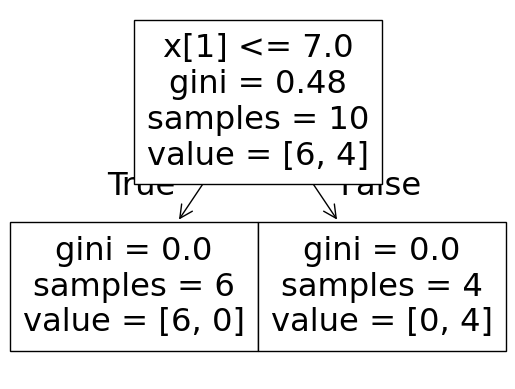

In [55]:
plot_tree(dt2)

<Axes: >

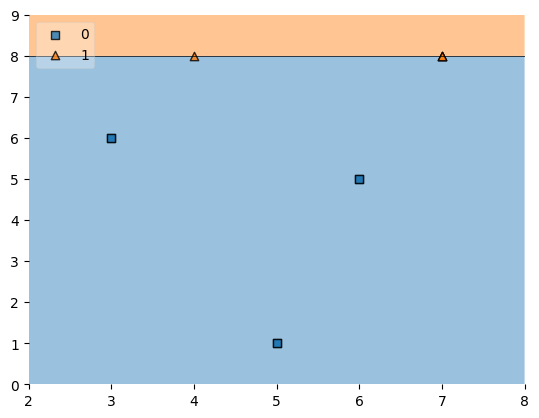

In [56]:
plot_decision_regions(x,y,clf=dt2,legend=2)

In [57]:
second_df['y_pred']=dt2.predict(x)

In [58]:
second_df

,X1,X2,label,weights,y_pred
2,3,6,0,0.1,0
7,7,8,1,0.1,1
7,7,8,1,0.1,1
2,3,6,0,0.1,0
3,4,8,1,0.1,1
4,5,1,0,0.1,0
6,6,5,0,0.1,0
4,5,1,0,0.1,0
7,7,8,1,0.1,1
6,6,5,0,0.1,0


In [59]:
alpha2=calculate_model_weight(0.1)

In [60]:
alpha2

np.float64(1.0986122886681098)

In [62]:
# step4 - update weights
def update_row_weights(row,alpha=1.09):
    if row['label'] == row['y_pred']:
        return row['weights']*np.exp(-alpha)
    else:
        return row['weights']*np.exp(alpha)

In [63]:
second_df['updated_weights']=second_df.apply(update_row_weights,axis=1)

In [64]:
second_df

,X1,X2,label,weights,y_pred,updated_weights
2,3,6,0,0.1,0,0.033622
7,7,8,1,0.1,1,0.033622
7,7,8,1,0.1,1,0.033622
2,3,6,0,0.1,0,0.033622
3,4,8,1,0.1,1,0.033622
4,5,1,0,0.1,0,0.033622
6,6,5,0,0.1,0,0.033622
4,5,1,0,0.1,0,0.033622
7,7,8,1,0.1,1,0.033622
6,6,5,0,0.1,0,0.033622
